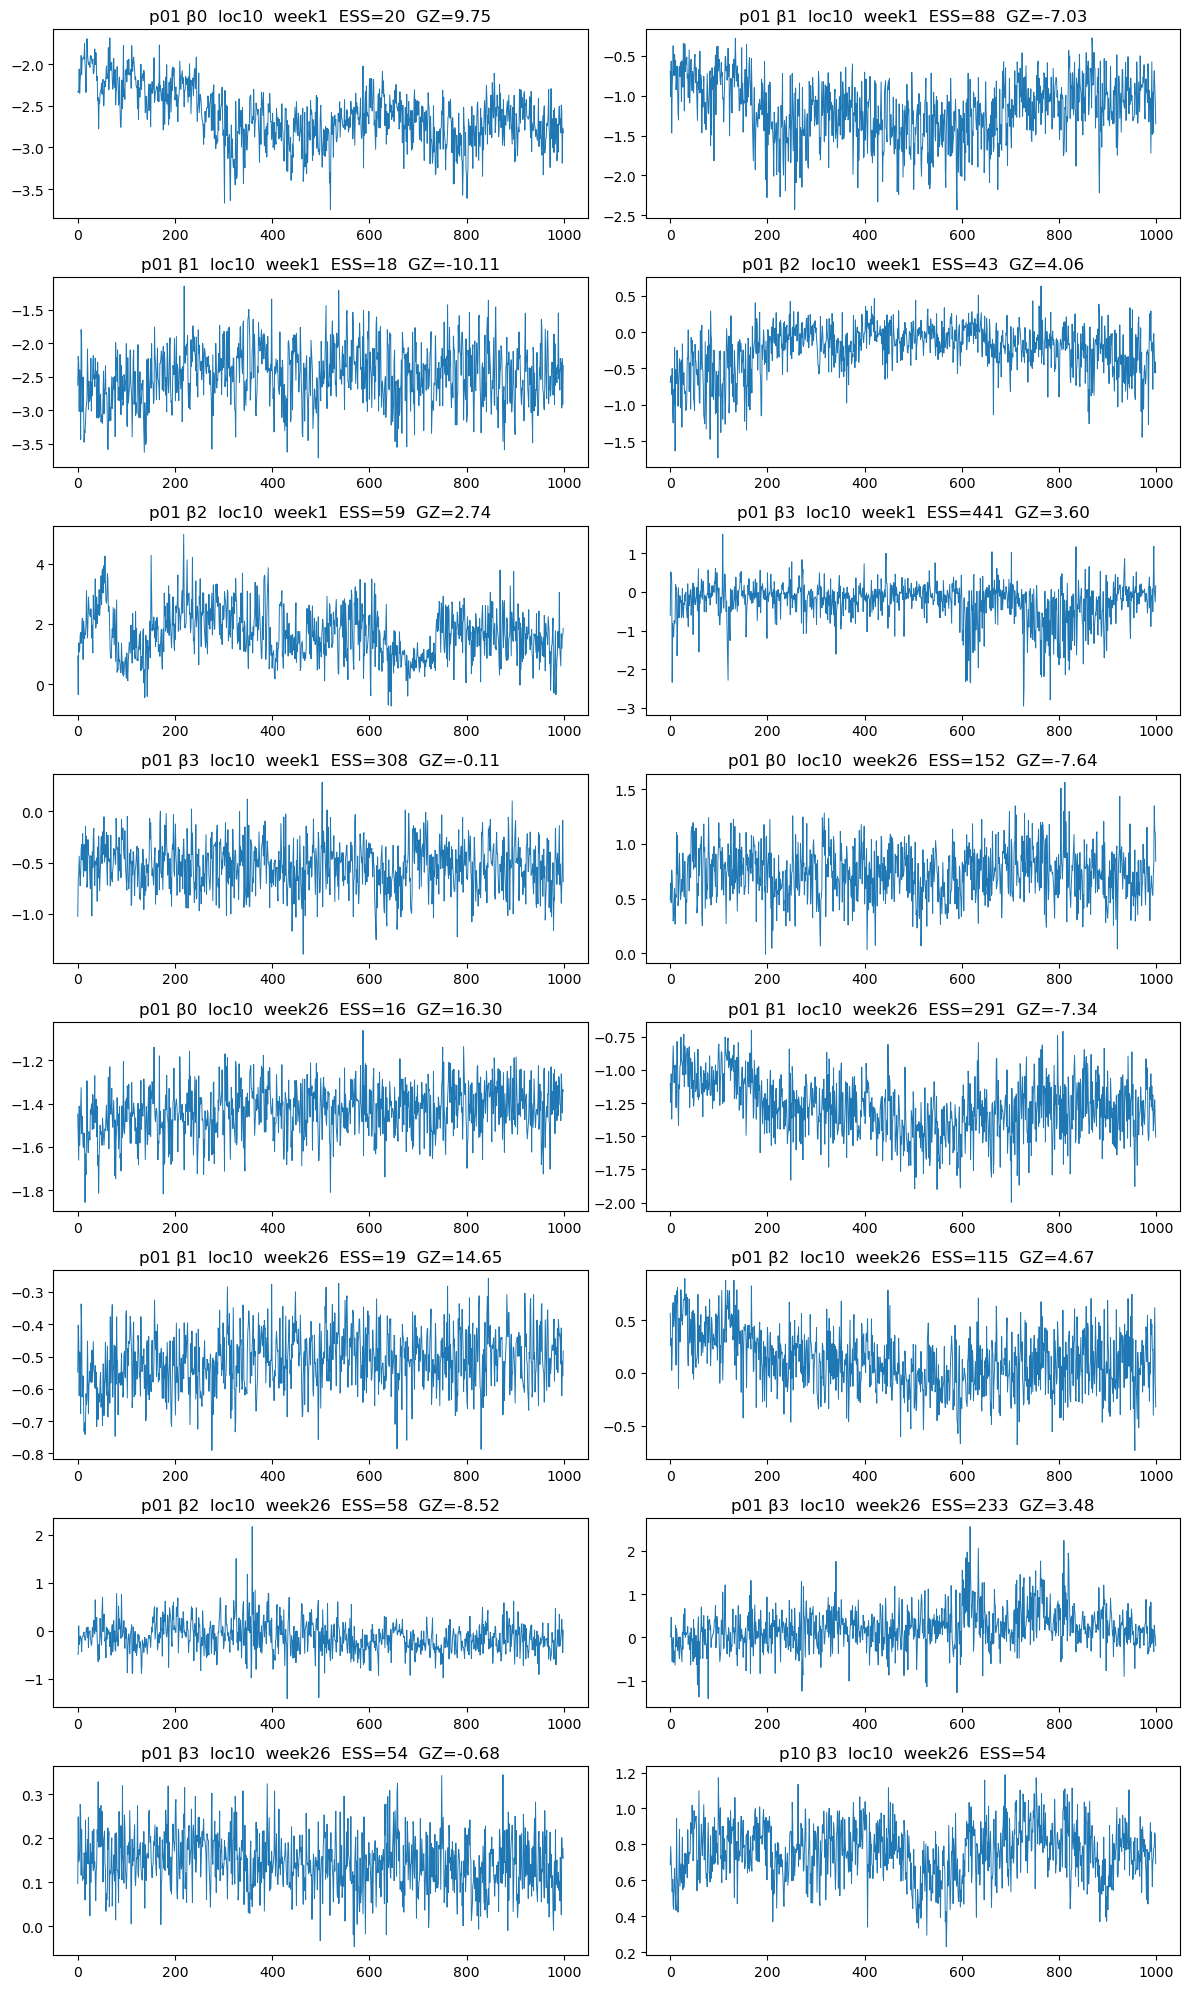

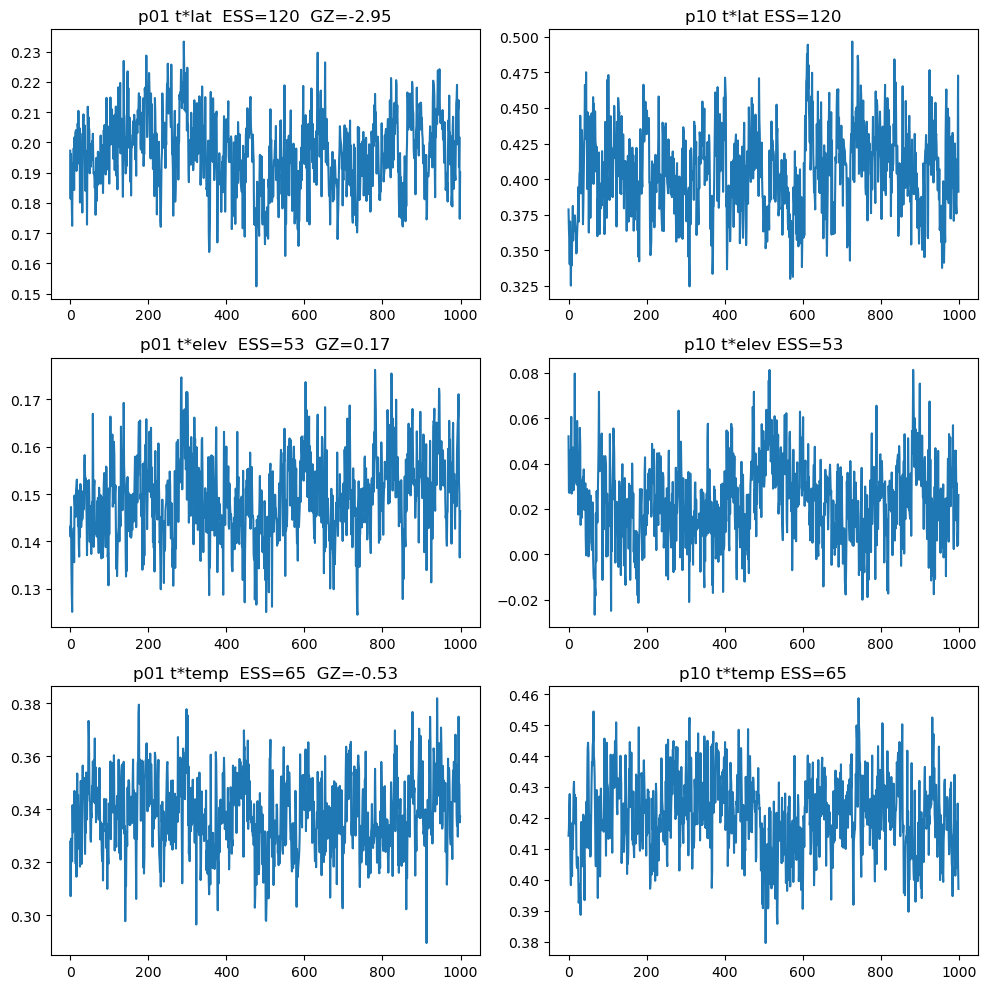

In [2]:
# ============================================================
# TRACEPLOTS for beta(s,t) and covariates
# ============================================================

import numpy as np
import pickle
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
# ------------------------------------------------------------
# ESS
# ------------------------------------------------------------
def compute_ess(x):

    x = np.asarray(x)
    n = len(x)

    x = x - x.mean()
    acov = np.correlate(x, x, mode='full')[n-1:] / n
    acf = acov / acov[0]

    s = 0
    for k in range(1, len(acf)):
        if acf[k] <= 0:
            break
        s += acf[k]

    ess = n / (1 + 2*s)

    return ess


# ------------------------------------------------------------
# Geweke statistic
# ------------------------------------------------------------
def geweke_z(x, first=0.1, last=0.5):

    x = np.asarray(x)
    n = len(x)

    n_first = int(first*n)
    n_last  = int(last*n)

    first_slice = x[:n_first]
    last_slice  = x[-n_last:]

    mean_diff = first_slice.mean() - last_slice.mean()

    var_first = np.var(first_slice)/len(first_slice)
    var_last  = np.var(last_slice)/len(last_slice)

    z = mean_diff / np.sqrt(var_first + var_last)

    return z


BASE_DIR = r"D:\77\Research\temp\snow"

p01_file = BASE_DIR + r"\bym01_cov_weekly_tau9.pkl"
p10_file = BASE_DIR + r"\bym10_cov_weekly_tau9.pkl"

K_base = 4
K_total = 8

summer_week = 26
winter_week = 1

loc1 = 10
loc2 = 200

# ------------------------------------------------------------
# ESS function
# ------------------------------------------------------------

def compute_ess(x):

    x = np.asarray(x)
    n = len(x)

    x = x - x.mean()
    acov = np.correlate(x, x, mode='full')[n-1:] / n
    acf = acov / acov[0]

    s = 0
    for k in range(1, len(acf)):
        if acf[k] <= 0:
            break
        s += acf[k]

    ess = n / (1 + 2*s)
    return ess


# ------------------------------------------------------------
# load samples
# ------------------------------------------------------------

def load_samples(file):

    with open(file,"rb") as f:
        res = pickle.load(f)

    eta = res["all_eta"]
    tau = res["all_tau"]
    S = res["S"]

    return eta, tau, S


eta01, tau01, S = load_samples(p01_file)
eta10, tau10, _ = load_samples(p10_file)

M = eta01.shape[1]

# ------------------------------------------------------------
# beta extractor
# ------------------------------------------------------------

def beta_trace(eta, tau, s, w, k):

    trace = np.zeros(M)

    for m in range(M):

        eta_icar = eta[(2*k)*S + s, m]
        eta_iid  = eta[(2*k+1)*S + s, m]

        tau_icar = tau[(2*k)*52 + w, m]
        tau_iid  = tau[(2*k+1)*52 + w, m]

        trace[m] = eta_icar*tau_icar + eta_iid*tau_iid

    return trace


# ------------------------------------------------------------
# build beta traces
# ------------------------------------------------------------

configs = [
    (loc1, winter_week),
    (loc1, summer_week),
    (loc2, winter_week),
    (loc2, summer_week)
]

beta_traces_p01 = []
beta_traces_p10 = []

labels = []

for s,w in configs:

    for k in range(K_base):

        beta_traces_p01.append(beta_trace(eta01,tau01,s,w,k))
        beta_traces_p10.append(beta_trace(eta10,tau10,s,w,k))

        labels.append(f"β{k}  loc{s}  week{w}")


# ------------------------------------------------------------
# PLOT beta traces
# ------------------------------------------------------------

fig, axes = plt.subplots(8,2, figsize=(12,20))

for i in range(8):

    tr = beta_traces_p01[i]
    ess = compute_ess(tr)
    gz  = geweke_z(tr)

    ax.set_title(
        f"p01 {labels[i]}  ESS={ess:.0f}  GZ={gz:.2f}"
    )

    ax = axes[i,0]
    ax.plot(tr, lw=0.7)
    ax.set_title(f"p01 {labels[i]}  ESS={ess:.0f}")

    tr = beta_traces_p10[i]
    ess = compute_ess(tr)
    gz  = geweke_z(tr)

    ax.set_title(
        f"p01 {labels[i]}  ESS={ess:.0f}  GZ={gz:.2f}"
    )

    ax = axes[i,1]
    ax.plot(tr, lw=0.7)
    ax.set_title(f"p10 {labels[i]}  ESS={ess:.0f}")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# COVARIATE traces
# ------------------------------------------------------------

gamma01 = eta01[K_total*S:K_total*S+3,:]
gamma10 = eta10[K_total*S:K_total*S+3,:]

names = ["t*lat","t*elev","t*temp"]

fig, axes = plt.subplots(3,2, figsize=(10,10))

for i in range(3):

    tr = gamma01[i]
    ess = compute_ess(tr)
    gz  = geweke_z(tr)

    axes[i,0].set_title(
        f"p01 {names[i]}  ESS={ess:.0f}  GZ={gz:.2f}"
    )

    axes[i,0].plot(tr)
    axes[i,0].set_title(f"p01 {names[i]} ESS={ess:.0f}")

    tr = gamma10[i]
    ess = compute_ess(tr)
    gz  = geweke_z(tr)

    axes[i,0].set_title(
        f"p01 {names[i]}  ESS={ess:.0f}  GZ={gz:.2f}"
    )

    axes[i,1].plot(tr)
    axes[i,1].set_title(f"p10 {names[i]} ESS={ess:.0f}")

plt.tight_layout()
plt.show()

